# Local environment version
The parts specific to the Google Colab version are commented out with #=#.<br>
The parts added in the local environment have #++ at the end of the line.<br>
Newly added cells in the local environment were placed under the Markdown cell beginning with ```#++ added new cell ++#```.<br>
I've added useful coding hints using Markdown blocks beginning with [HN], which means [Hints / Niigata-Univ H.Nishiyama version]<br>
original: https://github.com/TMDU-AI/AI-yodosha<br>
modified by H.Nishiyama, Niigata-Univ.<br>

# ローカル環境版
Google Colab 版特有の部分は #=# でコメントアウトしています。<br>
ローカル環境で追加した部分は行末に #++ が付いています。<br>
ローカル環境に新しく追加されたセルは、```#++ added new cell ++#``` で始まる Markdown セルの下に配置しました。<br>
[HN] で始まる Markdown ブロックを使用して、有用なコーディング ヒントを追加しました。これは  [Hints / Niigata-Univ H.Nishiyama version]を意味します。<br>
オリジナル: https://github.com/TMDU-AI/AI-yodosha<br>
新潟大学 H.Nishiyama が改訂しました。<br>

# **5章　肺のX線画像を用いた画像分類にトライしよう**

***[HN] 注意：サンプルデータを使って構築したシステムの性能はサンプルデータに依存するように学習されます。***<br>
このため、外部から持ち込んだデータを分類しようとすると、誤った回答を出力する可能性が高いので、注意しましょう。<br>
このような問題（バイアス）が発生する例を、過去の深層学習システム関連のニュースから検索し、レポートとして提出してください。<br>

※ここで構築したシステムと内部パラメータを、診断目的のために利用することは、決してしないようにしましょう。<br>
【参照】薬機法<br>
・プログラムの医療機器該当性に関するガイドラインについて（令和５年３月31日一部改正）［2.0MB］<br>
https://www.mhlw.go.jp/content/11120000/001082227.pdf<br>
のp.16（PDFでp.17）の「改訂後」（左側）<br>
＝＝＝<br>
脚注 12<br>
<p style="background-color:yellow;">
「当該プログラムは、疾病の診断、治療又は予防に使用されること<br>
を目的としていない」又は「当該プログラムは医療機器ではない」<br>
旨の記載、表示があることをもって、当該プログラムが医療機器で<br>
はないことの根拠とはならない。そのような記載があっても、疾病<br>
の疑いを判断できるなどと医療機器との認識を与える広告・標ぼう<br>
をする製品は医療機器に該当する。<br>
</p>
＝＝＝

# 5-1　ローカル環境版：圧縮ファイルの解凍

コード5-0

In [1]:
#=# from google.colab import drive
#=# drive.mount('/content/drive')
%pwd #++

'/home/hn/tf216c123/AI-yodosha-main/Chapter5'

コード5-1-1　images_TMDU.zipの解凍

***[HN] Windwosのコマンドを実行するセルはコメントを排除した独立したセルでないと動作しないため、下記をコメントアウトし、***<br>
***「#++ added new cell ++#」の部分に新たにセルを追加する形としています。***

In [2]:
#=# !unzip '/content/drive/MyDrive/images_TMDU.zip'

### #++ added new cell ++#
#### MacOS およびLinux用　（コメントアウトしています）

In [5]:
!unzip 'images_TMDU.zip' -d content

Archive:  images_TMDU.zip
   creating: content/images/
  inflating: content/__MACOSX/._images  
  inflating: content/images/.DS_Store  
  inflating: content/__MACOSX/images/._.DS_Store  
   creating: content/images/COVID-NORMAL/
  inflating: content/__MACOSX/images/._COVID-NORMAL  
  inflating: content/images/test.jpg  
  inflating: content/__MACOSX/images/._test.jpg  
  inflating: content/images/covid.jpg  
  inflating: content/__MACOSX/images/._covid.jpg  
  inflating: content/images/NORMAL.jpg  
  inflating: content/__MACOSX/images/._NORMAL.jpg  
   creating: content/images/COVID-NORMAL/covid19/
  inflating: content/__MACOSX/images/COVID-NORMAL/._covid19  
   creating: content/images/COVID-NORMAL/healthy/
  inflating: content/__MACOSX/images/COVID-NORMAL/._healthy  
  inflating: content/images/COVID-NORMAL/covid19/DX.1.2.840.113564.1722810162.20200410172247966360.1203801020003.jpg  
  inflating: content/__MACOSX/images/COVID-NORMAL/covid19/._DX.1.2.840.113564.1722810162.202004101722

### #++ added new cell ++#
#### Windows用

In [ ]:
%%cmd
chcp 65001
call powershell -command "Expand-Archive images_TMDU.zip -DestinationPath content -Force"

# 5-2　デジタル画像のデータは数値で表すことができる

コード5-2-1　画像「test.jpg」の読み込みと図示

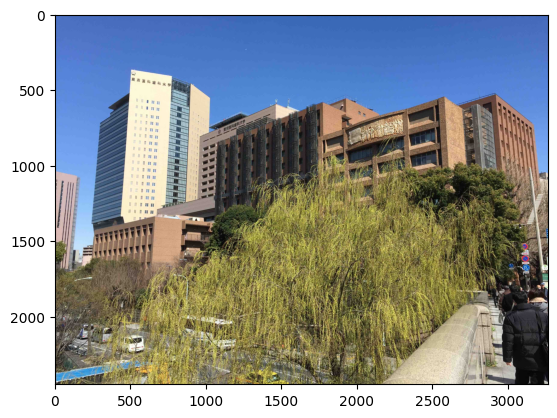

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=3264x2448 at 0x7F722D73D910>


In [6]:
import matplotlib.pyplot as plt
from keras.preprocessing.image import load_img
#=# test = load_img('/content/images/test.jpg', color_mode='rgb')
test = load_img('content/images/test.jpg', color_mode='rgb') #++
plt.imshow(test)
plt.show()
print(test)

コード5-2-2　画像サイズとカラーモードの変換

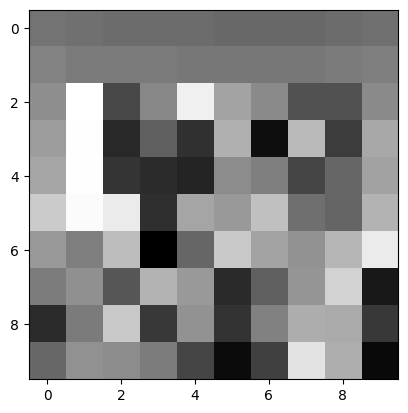

<PIL.Image.Image image mode=L size=10x10 at 0x7F722D61C050>


In [7]:
test2 = load_img(
    #=# '/content/images/test.jpg', color_mode='grayscale',
    'content/images/test.jpg', color_mode='grayscale', #++
    target_size=(10, 10))
plt.imshow(test2, 'gray')
plt.show()
print(test2)

コード5-2-3　画像データを配列データに変換

In [8]:
from keras.preprocessing.image import img_to_array
test2_img = img_to_array(test2)
print(type(test2_img))
print(test2_img)
print(test2_img.shape)

<class 'numpy.ndarray'>
[[[114.]
  [111.]
  [107.]
  [107.]
  [107.]
  [104.]
  [104.]
  [104.]
  [107.]
  [111.]]

 [[128.]
  [121.]
  [121.]
  [121.]
  [118.]
  [118.]
  [118.]
  [118.]
  [121.]
  [125.]]

 [[139.]
  [244.]
  [ 74.]
  [132.]
  [230.]
  [159.]
  [135.]
  [ 82.]
  [ 83.]
  [135.]]

 [[153.]
  [243.]
  [ 45.]
  [ 95.]
  [ 53.]
  [170.]
  [ 20.]
  [179.]
  [ 63.]
  [163.]]

 [[161.]
  [243.]
  [ 56.]
  [ 47.]
  [ 42.]
  [137.]
  [125.]
  [ 71.]
  [102.]
  [157.]]

 [[195.]
  [240.]
  [225.]
  [ 51.]
  [160.]
  [149.]
  [185.]
  [110.]
  [101.]
  [174.]]

 [[149.]
  [125.]
  [182.]
  [  7.]
  [102.]
  [194.]
  [158.]
  [143.]
  [176.]
  [225.]]

 [[122.]
  [141.]
  [ 87.]
  [174.]
  [149.]
  [ 46.]
  [ 95.]
  [145.]
  [202.]
  [ 30.]]

 [[ 47.]
  [121.]
  [193.]
  [ 60.]
  [143.]
  [ 55.]
  [127.]
  [168.]
  [165.]
  [ 60.]]

 [[103.]
  [142.]
  [137.]
  [122.]
  [ 71.]
  [ 18.]
  [ 67.]
  [219.]
  [169.]
  [ 16.]]]
(10, 10, 1)


コード5-2-4　画像サイズ(10, 10)，カラーでの図示と配列変換

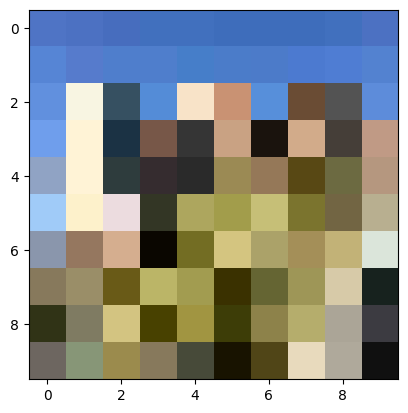

[[[ 79. 116. 197.]
  [ 76. 113. 194.]
  [ 71. 109. 190.]
  [ 65. 112. 190.]
  [ 65. 112. 190.]
  [ 62. 109. 187.]
  [ 62. 109. 187.]
  [ 62. 109. 187.]
  [ 65. 112. 190.]
  [ 76. 113. 194.]]

 [[ 86. 133. 213.]
  [ 86. 123. 204.]
  [ 79. 126. 204.]
  [ 79. 126. 204.]
  [ 70. 126. 201.]
  [ 75. 124. 201.]
  [ 76. 123. 201.]
  [ 76. 122. 208.]
  [ 79. 125. 211.]
  [ 83. 130. 208.]]

 [[ 97. 144. 222.]
  [248. 245. 226.]
  [ 54.  80.  97.]
  [ 84. 140. 215.]
  [248. 227. 200.]
  [201. 146. 115.]
  [ 87. 143. 218.]
  [106.  76.  52.]
  [ 83.  83.  83.]
  [ 93. 140. 218.]]

 [[111. 158. 236.]
  [255. 243. 214.]
  [ 27.  50.  68.]
  [119.  87.  72.]
  [ 53.  53.  53.]
  [201. 162. 131.]
  [ 26.  19.  13.]
  [210. 171. 138.]
  [ 69.  62.  56.]
  [192. 154. 133.]]

 [[144. 163. 196.]
  [255. 243. 214.]
  [ 46.  60.  61.]
  [ 53.  44.  47.]
  [ 42.  42.  42.]
  [155. 138.  84.]
  [149. 120.  88.]
  [ 88.  72.  20.]
  [108. 106.  65.]
  [181. 151. 127.]]

 [[160. 203. 248.]
  [253. 241. 203.]
  

In [9]:
test3 = load_img(
    #=# '/content/images/test.jpg', color_mode='rgb', target_size=(10, 10))
    'content/images/test.jpg', color_mode='rgb', target_size=(10, 10)) #++
plt.imshow(test3)
plt.show()
test3_img = img_to_array(test3)
print(test3_img)
print(test3_img.shape)

コード5-2-5　インデックスによるデータへのアクセス

In [10]:
# (10, 10, 3)は，10行あり，その各行は10列あり，その各列に3つの色要素が格納
print(len(test3_img))       # 「test3_img」の値の長さ（要素数；行数）を表示
print(test3_img[0])         # その0番行「test3_img[0]」の値を表示
print(len(test3_img[0]))    # その0番行の値の長さ（要素数；列数）を表示
print(test3_img[0][0])      # その0番行，0番列「test3_img[0][0]」の値を表示
print(len(test3_img[0][0])) # その値の長さ（要素数）を表示
print(test3_img[0][0][0])   # その0番行，0番列，0番要素（Red）の値を表示

10
[[ 79. 116. 197.]
 [ 76. 113. 194.]
 [ 71. 109. 190.]
 [ 65. 112. 190.]
 [ 65. 112. 190.]
 [ 62. 109. 187.]
 [ 62. 109. 187.]
 [ 62. 109. 187.]
 [ 65. 112. 190.]
 [ 76. 113. 194.]]
10
[ 79. 116. 197.]
3
79.0


# 5-3　肺のX線画像の分類モデルを作成してみよう

**STEP1　肺のX線画像ファイルのリスト作成**

コード5-3-1　ファイル名のリストを作成

In [11]:
import os
list_healthy = [
    #=# i for i in os.listdir('/content/images/COVID-NORMAL/healthy')
    i for i in os.listdir('content/images/COVID-NORMAL/healthy') #++
    if not i.startswith('.')]
list_covid19 = [
    #=# i for i in os.listdir('/content/images/COVID-NORMAL/covid19')
    i for i in os.listdir('content/images/COVID-NORMAL/covid19') #++
    if not i.startswith('.')]
print(len(list_healthy))
print(len(list_covid19))

116
116


コード5-3-2　リスト内包表記の例１

In [12]:
example1 = [i for i in range(5)]
print(example1)
temp = [1, 3, 5, 7, 9]
example2 = [i*2 for i in temp]
print(example2)

[0, 1, 2, 3, 4]
[2, 6, 10, 14, 18]


コード5-3-3　リスト内包表記の例２

In [13]:
temp = [1, 3, 5, 7, 9]
example3 = [i*2 for i in temp if i > 4]
print(example3)
example4 = [i*2 for i in temp if not i > 5]
print(example4)

[10, 14, 18]
[2, 6, 10]


コード5-3-4　リスト内包表記の例３

In [14]:
temp2 = ['須藤', '佐藤', '加藤', '佐川']
example5 = [name for name in temp2 if name.startswith('佐')]
print(example5)
example6 = [name for name in temp2 if not name.endswith('藤')]
print(example6)

['佐藤', '佐川']
['佐川']


コード5-3-5　os.listdir()の確認１

In [15]:
import os
#=# os.listdir('/content/images/COVID-NORMAL')
os.listdir('content/images/COVID-NORMAL') #++

['healthy', 'covid19']

コード5-3-6　os.listdir()の確認２

In [16]:
#=# os.listdir('/content/images/COVID-NORMAL/healthy')
os.listdir('content/images/COVID-NORMAL/healthy') #++

['DX.1.2.840.113564.1722810162.20200416130101712300.1203801020003.jpg',
 'CR.1.2.840.113564.1921681134.20200409131843311120.1203801020003.jpg',
 'DX.1.2.840.113564.1722810162.20200417111010040980.1203801020003.jpg',
 'DX.1.2.840.113564.1722810162.20200416191632203540.1203801020003.jpg',
 'DX.1.2.840.113564.1722810162.20200407110159061830.1203801020003.jpg',
 'DX.1.2.840.113564.1722810162.20200409122112986890.1203801020003.jpg',
 'DX.1.2.840.113564.1722810162.20200331235358718640.1203801020003.jpg',
 'DX.1.2.840.113564.1722810162.20200328170109600900.1203801020003.jpg',
 'DX.1.2.840.113564.1722810162.20200415172911278870.1203801020003.jpg',
 'DX.1.2.840.113564.1722810162.20200325180923403640.1203801020003.jpg',
 'DX.1.2.840.113564.1722810162.20200409131002213950.1203801020003.jpg',
 'CR.1.2.840.113564.192168196.2020031913094890017.1203801020003.jpg',
 'DX.1.2.840.113564.1722810162.20200406152138599630.1203801020003.jpg',
 'DX.1.2.840.113564.1722810162.20200331165352707460.1203801020003.

**STEP2　画像ファイル数の集計と変数の作成**

コード5-3-7　画像ファイル数の集計

In [17]:
num_healthy = len(list_healthy)
num_covid19 = len(list_covid19)
num_all = num_healthy + num_covid19
print(num_all)

232


コード5-3-8　画像データ格納用NumPy配列の作成

In [18]:
import numpy as np
images_temp = np.zeros((num_all, 64, 64, 1), dtype=float)
labels_temp = np.zeros((num_all, 1), dtype=int)
print(images_temp.shape)
print(labels_temp.shape)

(232, 64, 64, 1)
(232, 1)


コード5-3-9　画像データ格納用NumPy配列の値の確認

In [19]:
print(labels_temp)
print(images_temp[0])

[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]


**STEP3　健康な肺のX線画像の読み込み**

コード5-3-10　画像の読み込み（list_healthy）



In [20]:
#=# path_healthy = '/content/images/COVID-NORMAL/healthy'
path_healthy = 'content/images/COVID-NORMAL/healthy' #++
for i in range(num_healthy):
  file = f'{path_healthy}/{list_healthy[i]}'
  file_img = load_img(
      file, color_mode='grayscale', target_size=(64, 64),
      interpolation='lanczos')
  images_temp[i] = img_to_array(file_img) / 255
  labels_temp[i] = 0

コード5-3-11　「f'{変数名}'」の例

In [21]:
name = '須藤'
print('name')
print(f'{name}')
print('私の名前はnameです')
print(f'私の名前は{name}です')

name
須藤
私の名前はnameです
私の名前は須藤です


コード5-3-12　images_tempの変換後の値

In [22]:
images_temp[0]

array([[[0.08627451],
        [0.07450981],
        [0.05882353],
        ...,
        [0.03529412],
        [0.04313726],
        [0.04705882]],

       [[0.04705882],
        [0.04705882],
        [0.07450981],
        ...,
        [0.00784314],
        [0.02352941],
        [0.03529412]],

       [[0.14117648],
        [0.23921569],
        [0.30588236],
        ...,
        [0.10196079],
        [0.03529412],
        [0.01568628]],

       ...,

       [[0.14117648],
        [0.33725491],
        [0.4627451 ],
        ...,
        [0.04705882],
        [0.05490196],
        [0.05490196]],

       [[0.11372549],
        [0.3137255 ],
        [0.43529412],
        ...,
        [0.05098039],
        [0.05490196],
        [0.05882353]],

       [[0.08235294],
        [0.29019609],
        [0.40000001],
        ...,
        [0.05490196],
        [0.05490196],
        [0.05882353]]])

**STEP4　肺炎のX線画像の読み込み**

コード5-3-13　画像の読み込み（list_covid19）

In [23]:
#=# path_covid19 = '/content/images/COVID-NORMAL/covid19'
path_covid19 = 'content/images/COVID-NORMAL/covid19' #++
for i in range(num_covid19):
  file = f'{path_covid19}/{list_covid19[i]}'
  file_img = load_img(
      file, color_mode='grayscale', target_size=(64, 64),
      interpolation='lanczos')
  images_temp[i + num_healthy] = img_to_array(file_img) / 255
  labels_temp[i + num_healthy] = 1

コード5-3-14　images_tempとlabels_tempの変換後の値

In [24]:
print(images_temp[116])
print(labels_temp[116])

[[[0.10588235]
  [0.10196079]
  [0.09411765]
  ...
  [0.02745098]
  [0.03529412]
  [0.03529412]]

 [[0.09803922]
  [0.08235294]
  [0.05882353]
  ...
  [0.01960784]
  [0.01960784]
  [0.02352941]]

 [[0.06666667]
  [0.08235294]
  [0.18039216]
  ...
  [0.09803922]
  [0.05882353]
  [0.03137255]]

 ...

 [[0.12156863]
  [0.09803922]
  [0.12156863]
  ...
  [0.40000001]
  [0.25882354]
  [0.10588235]]

 [[0.12156863]
  [0.10588235]
  [0.09019608]
  ...
  [0.3764706 ]
  [0.22745098]
  [0.06666667]]

 [[0.12156863]
  [0.11372549]
  [0.07058824]
  ...
  [0.3137255 ]
  [0.16862746]
  [0.03921569]]]
[1]


**STEP5　X線画像のシャッフル**

コード5-3-15　0から231までの数字の配列を作成

In [25]:
num_list = np.arange(num_all)
print(num_list)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231]


コード5-3-16　NumPy配列をシャッフルする

In [26]:
np.random.seed(111)
np.random.shuffle(num_list)
print(num_list)

[155 159 132 206 145  18  73  55 205  11 222 202  38  83  56  65 148 219
 158 144  39 128  63 100  23  81 176 115  35 192 102 120  49   9 122 214
   3 116 154 228  71  25 184 150 171  85  67   0 183 111   2  30  47 129
 117  26  15  57 180 125   6 191  52  41  29  24 226 189  87 194 153 223
  99  58 167 104 109 156 114 230 126 175  92  43  76  16 136 172 130 216
  93  22 146  79 127  45 181 106 168 138 211 224 231  95  36 208 188  90
  60 152  98  53 227  44  20  80 163 124   8  70 151  77  72  82 213 113
 149 142 190  46 178 225 218 110   5 107 164  32 174 143 101  34  48  61
  96 133  89 161  51 141 195 119  27 121  42  91 165 221  75  62 196 105
 182 209 135 160  33  69 207 131 140 215   1  64  94 203 134 201 179 123
 187 103 177 139  74  17   4 220  59 166  97 147 170 137 157  68  50  13
 198  88  31  78 197 173 217 186 204  37 200  54  21 162  14  28 112 193
  10  12   7 185 199  40 210 118  66 169  19  86 229 212 108  84]


コード5-3-17　images_tempとlabels_tempの配列をシャッフルする

In [27]:
print(labels_temp[0:10])
x_train = images_temp[num_list]
y_train = labels_temp[num_list]
print(y_train[0:10])
print(x_train.shape)
print(y_train.shape)

[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]
[[1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]]
(232, 64, 64, 1)
(232, 1)


コード5-3-18　NumPy配列の要素を並べ替える

In [28]:
array1 = np.array([10, 20, 30, 40, 50])
print(array1)
order = [3, 2, 0, 4, 1]
array2 = array1[order]
print(array2)

[10 20 30 40 50]
[40 30 10 50 20]


**STEP6　深層学習モデルの作成**

コード5-3-19　深層学習モデルの作成

In [29]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

model = Sequential()
model.add(Flatten(input_shape=(64, 64, 1))) # 配列を1次元に変換
model.add(Dense(512, activation='relu'))  # 中間層1層目を作成
model.add(Dense(256, activation='relu'))  # 中間層2層目を作成
model.add(Dense(128, activation='relu'))  # 中間層3層目を作成
model.add(Dense(1, activation='sigmoid')) # 出力層を作成
model.compile(
    loss='binary_crossentropy', optimizer='Adam',
    metrics=['accuracy']) # 学習方法の設定
model.summary()

/home/hn/tf216c123/.venv/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-01-10 12:48:54.478532: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:65:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-10 12:48:55.787899: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:65:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-10 12:48:55.788044: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:65:00.0/numa_node
Your kernel may have been built without NUMA s

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,262,017 (8.63 MB)

 Trainable params: 2,262,017 (8.63 MB)

 Non-trainable params: 0 (0.00 B)

コード5-3-20　学習の実施

In [30]:
result = model.fit(
    x_train, y_train, batch_size=32, epochs=100, validation_split=0.2)

Epoch 1/100


I0000 00:00:1736480943.475666   12550 service.cc:145] XLA service 0x7f71000054e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1736480943.475767   12550 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2025-01-10 12:49:03.739694: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-01-10 12:49:04.443471: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1736480945.989230   12636 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_417', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1736480946.201495   12638 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_417', 40 bytes spill stores, 40 bytes spill loads

I0000 00:00:17

1/6 ━━━━━━━━━━━━━━━━━━━━ 31s 6s/step - accuracy: 0.4062 - loss: 0.7291

I0000 00:00:1736480948.197067   12550 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1736480949.621249   12755 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_417', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1736480949.642329   12748 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_417', 40 bytes spill stores, 40 bytes spill loads

I0000 00:00:1736480949.650560   12751 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_417', 32 bytes spill stores, 32 bytes spill loads

I0000 00:00:1736480949.721105   12747 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_419', 4 bytes spill stores, 4 bytes spill loads



6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.4580 - loss: 1.8649

I0000 00:00:1736480952.967869   12916 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_36', 8 bytes spill stores, 8 bytes spill loads



6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.4636 - loss: 1.8452 - val_accuracy: 0.4681 - val_loss: 1.1579
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5009 - loss: 0.9024 - val_accuracy: 0.4681 - val_loss: 0.8210
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5027 - loss: 0.8028 - val_accuracy: 0.4681 - val_loss: 0.8097
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5449 - loss: 0.7754 - val_accuracy: 0.5532 - val_loss: 0.6610
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6101 - loss: 0.6296 - val_accuracy: 0.7021 - val_loss: 0.5930
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7499 - loss: 0.5799 - val_accuracy: 0.5106 - val_loss: 0.7114
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5861 - loss: 0.6717 - val_accuracy: 0.7234 - val_loss: 0.5595
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6843 - loss: 0.6006 - val_accuracy: 0.5957 - val_loss: 0.7328
Epoch

コード5-3-21　学習過程の図示

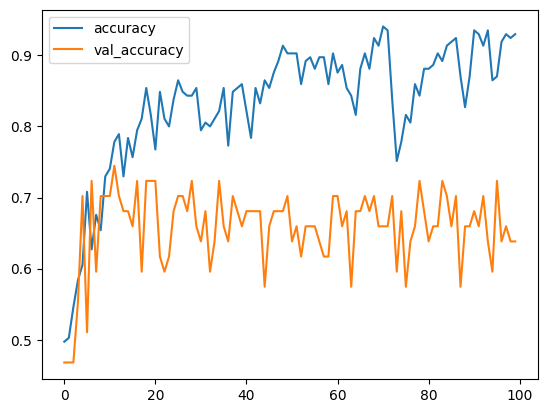

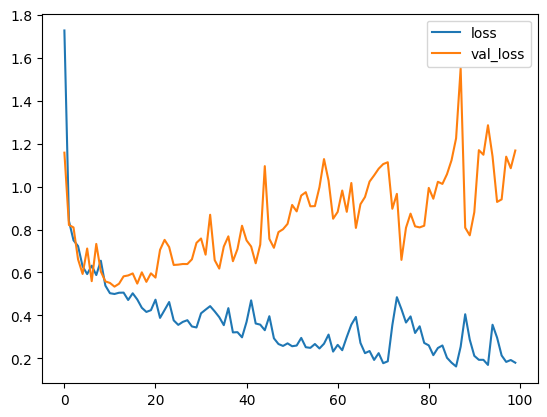

In [31]:
import matplotlib.pyplot as plt
plt.plot(result.history['accuracy'], label='accuracy')
plt.plot(result.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()
plt.plot(result.history['loss'], label='loss')
plt.plot(result.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

コード5-3-22　Dropoutを加えて過学習を防ぐ

In [32]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout # Dropout関数を追加

model = Sequential()
model.add(Flatten(input_shape=(64, 64, 1)))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5)) # Dropoutの層を追加
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5)) # Dropoutの層を追加
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(
    loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])
model.summary()
result = model.fit(
    x_train, y_train, batch_size=32, epochs=100, validation_split=0.2)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,262,017 (8.63 MB)

 Trainable params: 2,262,017 (8.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4979 - loss: 1.1586 - val_accuracy: 0.5319 - val_loss: 1.0401
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5540 - loss: 1.4418 - val_accuracy: 0.4681 - val_loss: 1.2424
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4542 - loss: 1.7873 - val_accuracy: 0.4681 - val_loss: 1.0381
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5170 - loss: 1.1075 - val_accuracy: 0.4681 - val_loss: 0.8162
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4854 - loss: 1.0265 - val_accuracy: 0.5319 - val_loss: 0.6905
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4878 - loss: 0.9914 - val_accuracy: 0.4681 - val_loss: 0.6847
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5606 - loss: 0.8111 - val_accuracy: 0.5532 - val_loss: 0.6649
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5051 - loss: 0.8256 - val_accuracy: 0.5319 - val_loss: 

コード5-3-23　Dropoutを加えた学習過程の図示

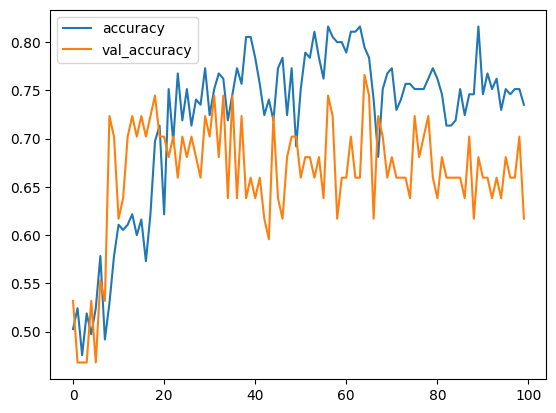

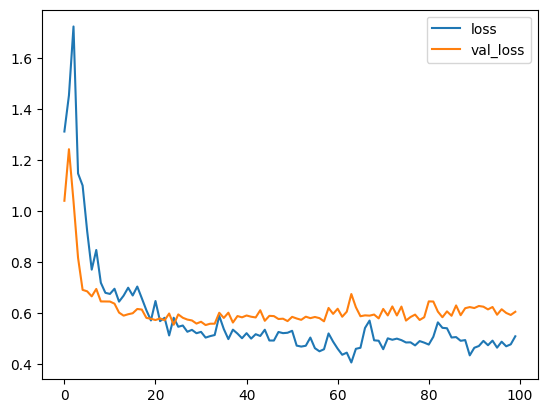

In [33]:
import matplotlib.pyplot as plt
plt.plot(result.history['accuracy'], label='accuracy')
plt.plot(result.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()
plt.plot(result.history['loss'], label='loss')
plt.plot(result.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

# 5-4　未知のデータが肺炎かどうかを予測

コード5-4-1　新たな画像での分類

In [34]:
img1 = img_to_array(load_img(
    #=# '/content/images/covid.jpg',
    'content/images/covid.jpg', #++
    color_mode='grayscale', target_size=(64, 64))) / 255
img2 = img_to_array(load_img(
    #=# '/content/images/NORMAL.jpg',
    'content/images/NORMAL.jpg', #++
    color_mode='grayscale', target_size=(64, 64))) / 255
check = np.zeros((2, 64, 64, 1))
check[0] = img1
check[1] = img2
prob = model.predict(check)
print(prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[[0.9339964 ]
 [0.17227656]]
